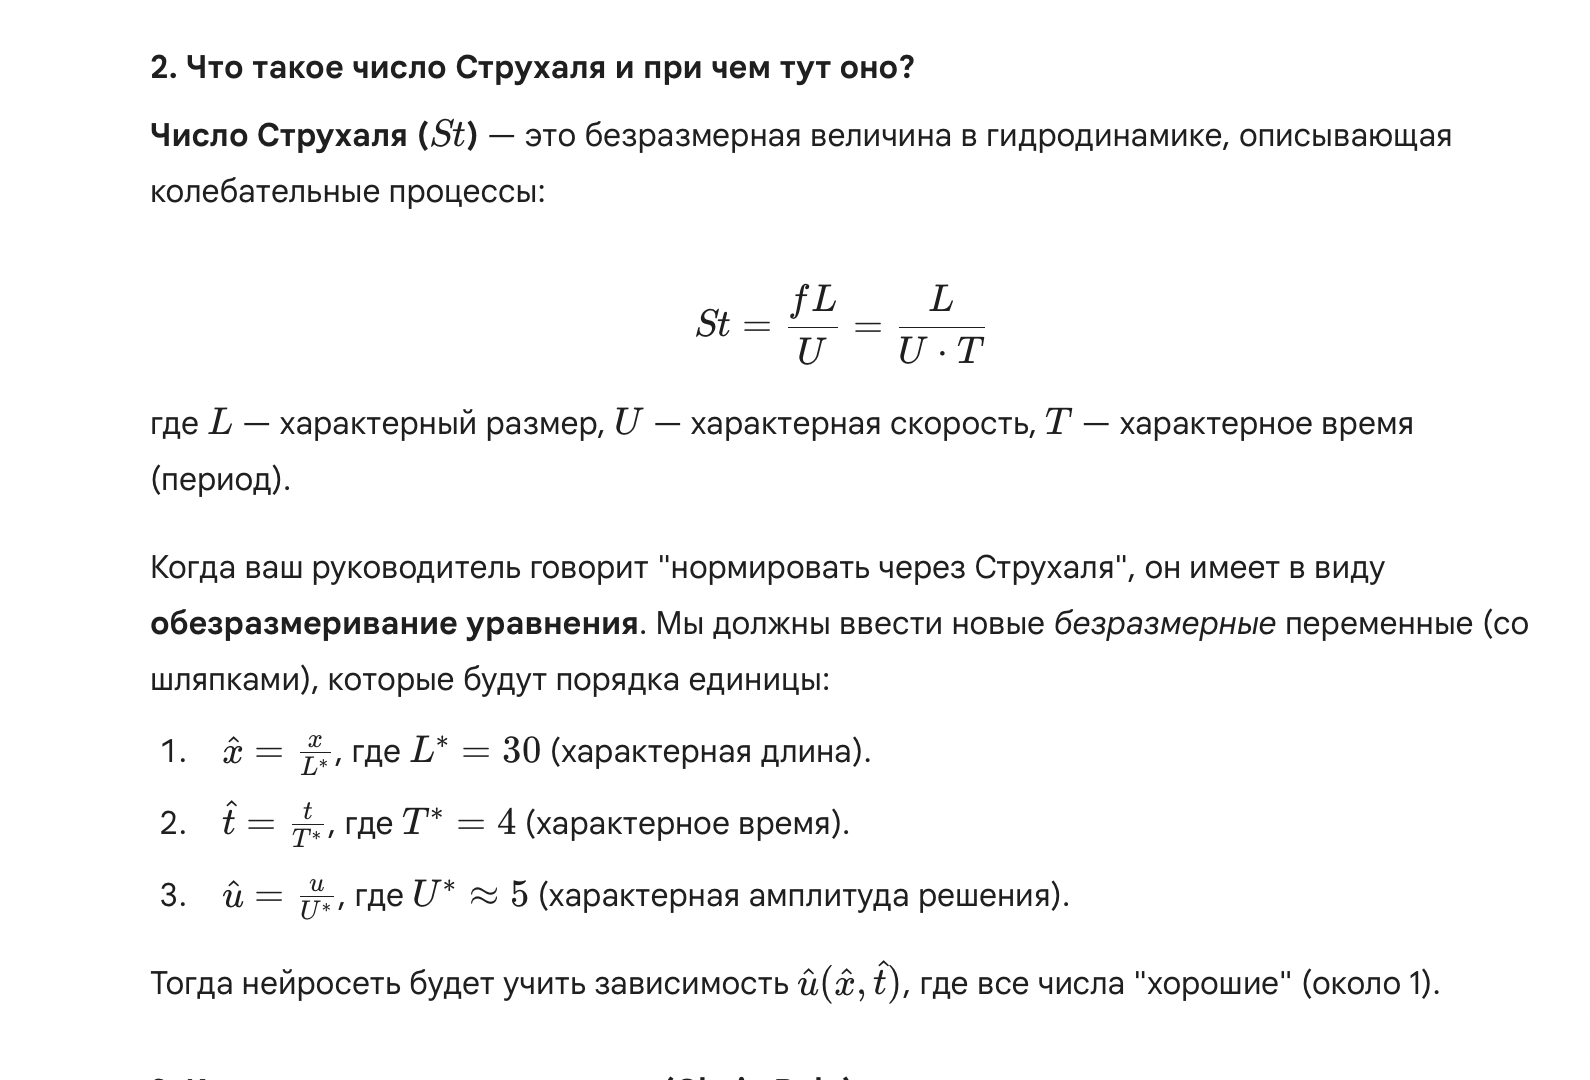

# Потановка задачи 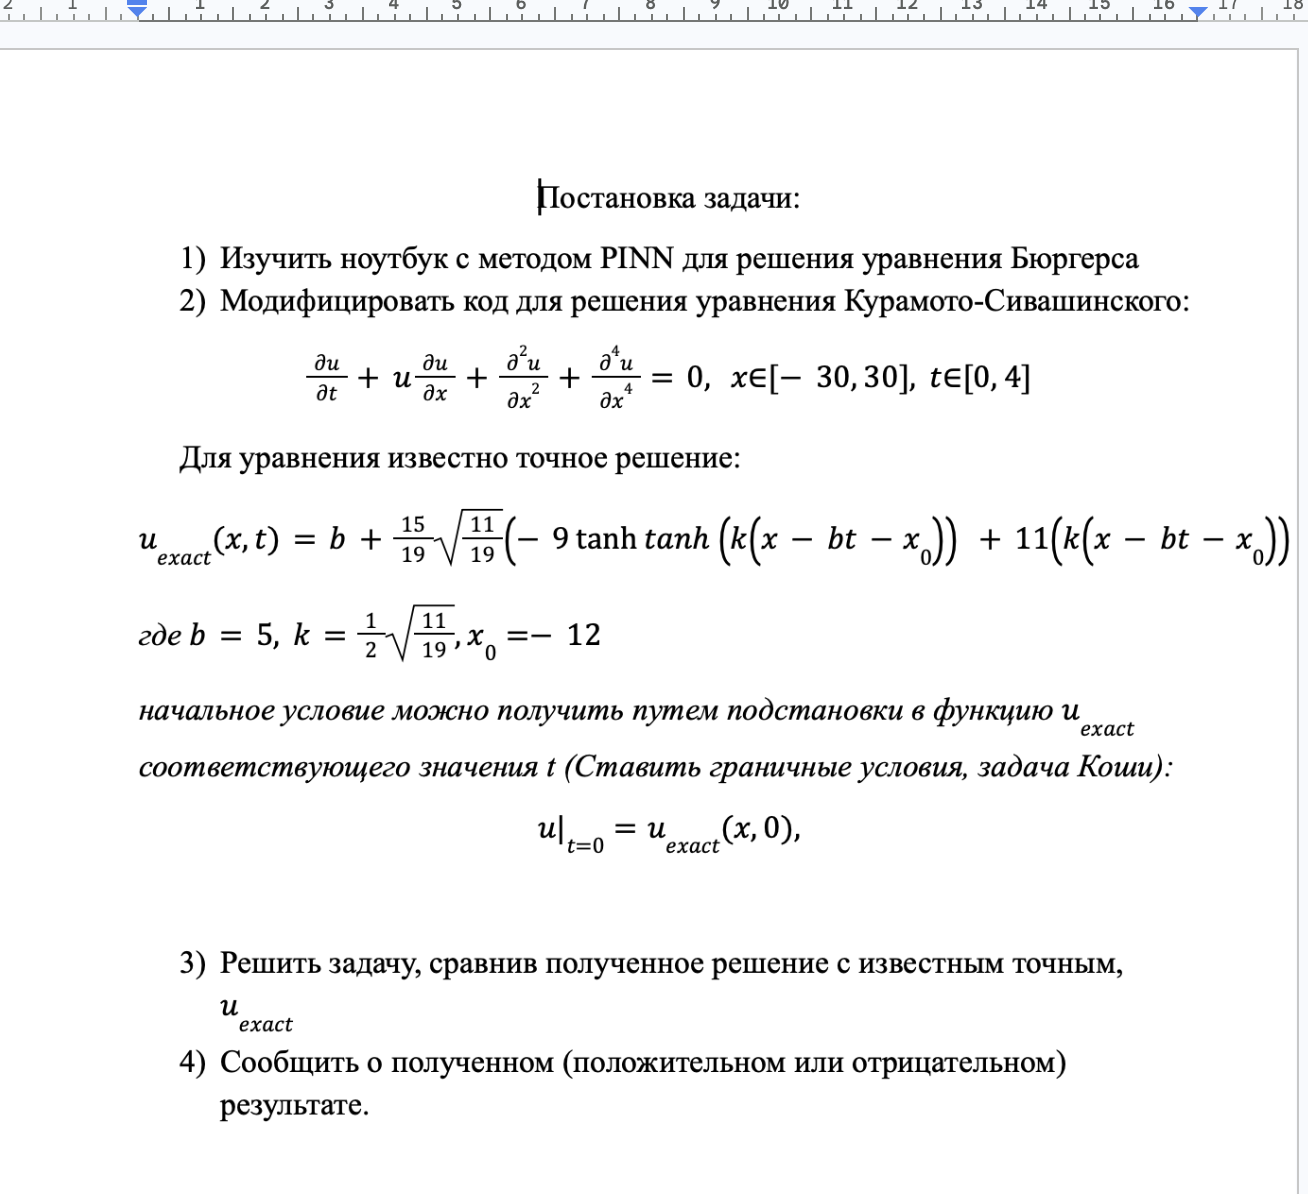
## Уравнение диф
$$ u_t+ u \cdot u_x + u_{xx} + u_{xxxx} = 0 , x \in [30,30], t \in [0,4]$$
## Точное решение 

# Init imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path
from time import time

try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


/Users/zasmina/Study/6-semester/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


tf_fourier_features is not available.
Install with: pip install tf-fourier-features
Using fallback Fourier features. Import error: No module named 'tf_fourier_features'


# Init Data

In [2]:
DTYPE = "float64"
tf.keras.backend.set_floatx(DTYPE)

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

b = tf.constant(5.0, dtype=DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE)
x0 = tf.constant(-12.0, dtype=DTYPE)
us = tf.constant(10.0, dtype=DTYPE)


def u_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


- linspace равновмерный выбор точек на отрезке
- reshape изменение формы массива (в даннном случаи транспонировали вектор)

In [3]:
x = np.linspace(-30.0, 30.0, 200).reshape(-1, 1)


### Постронение графика в точке (0, x) 

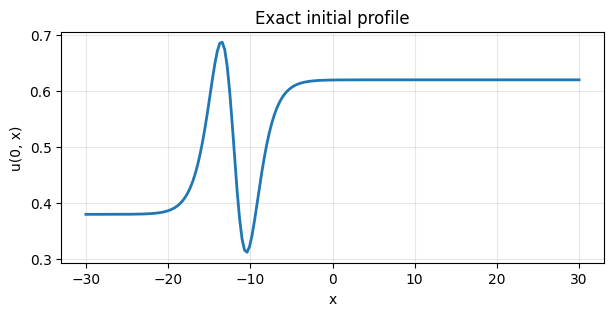

In [4]:
plt.figure(figsize=(7, 3))
plt.plot(x, u_exact(0.0, x), lw=2)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Exact initial profile")
plt.grid(True, alpha=0.3)
plt.show()


# Начальное условие 

In [5]:
def fun_u_0(x):
    return u_exact(tf.zeros_like(x, dtype=DTYPE), x)


# Функции описывающие невязки 


In [6]:
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx):
    return u_t + us * u * u_x + u_xx + u_xxxx


# Параметры области 

Параметры 
tmin = 0.; tmax = 4.  

xmin = -30.; xmax = 30.  Надо изменить ? получается если нормализируем в этой функции 

In [7]:
N_0 = 300
N_r = 20000
N_b = 2000

tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0


# Границы области

In [8]:
lb = tf.constant([tmin, xmin], dtype=DTYPE)
ub = tf.constant([tmax, xmax], dtype=DTYPE)


In [9]:
# Initial condition points: t = 0
t_0 = tf.zeros((N_0, 1), dtype=DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)
u_0 = fun_u_0(x_0)


### Так понимаю это задание обучающего датасета 
выбираем рандомные точки для обучения (см график)

In [10]:
# Collocation points inside the time-space domain
t_r = tf.random.uniform((N_r, 1), lb[0] + 1e-6, ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)


Граничные условия 


In [11]:
# Boundary points: x = xmin and x = xmax at identical time t_b
t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)

x_lb = tf.ones((N_b, 1), dtype=DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=DTYPE) * ub[1]

X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

tf.debugging.assert_near(X_lb[:, 0:1], X_ub[:, 0:1])


In [12]:
# Boundary sample sanity check
print("X_lb shape:", X_lb.shape, "X_ub shape:", X_ub.shape)
print("Same time samples on left/right:", bool(tf.reduce_all(tf.equal(X_lb[:, 0:1], X_ub[:, 0:1]))))
print("Unique x on left boundary:", np.unique(X_lb[:, 1].numpy())[:5])
print("Unique x on right boundary:", np.unique(X_ub[:, 1].numpy())[:5])


X_lb shape: (2000, 2) X_ub shape: (2000, 2)
Same time samples on left/right: True
Unique x on left boundary: [-30.]
Unique x on right boundary: [30.]


In [13]:
X_data = [X_0]
u_data = [u_0]


# График точного решения 

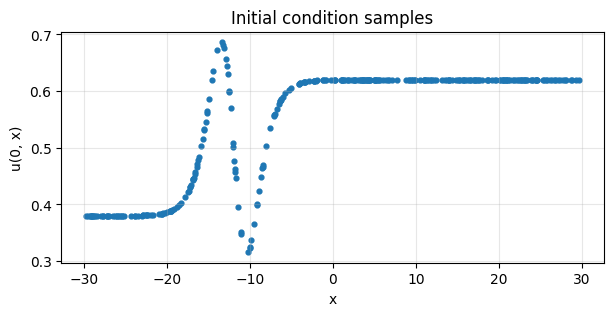

In [14]:
plt.figure(figsize=(7, 3))
plt.scatter(X_0[:, 1:2], u_0, s=12)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Initial condition samples")
plt.grid(True, alpha=0.3)
plt.show()


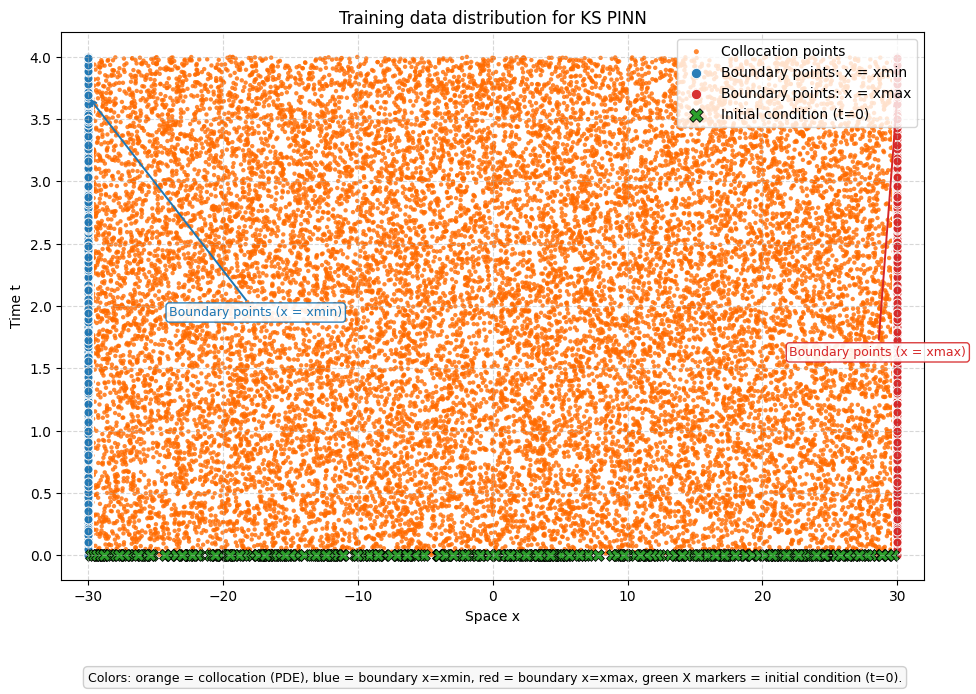

In [15]:
fig = plt.figure(figsize=(10, 7))

plt.scatter(
    x_r,
    t_r,
    c="#ff6b00",
    marker="o",
    s=10,
    alpha=0.80,
    edgecolors="none",
    label="Collocation points",
)

plt.scatter(
    x_lb,
    t_b,
    c="#1f77b4",
    marker="o",
    s=42,
    alpha=0.95,
    edgecolors="white",
    linewidths=0.7,
    label="Boundary points: x = xmin",
)

plt.scatter(
    x_ub,
    t_b,
    c="#d62728",
    marker="o",
    s=42,
    alpha=0.95,
    edgecolors="white",
    linewidths=0.7,
    label="Boundary points: x = xmax",
)

plt.scatter(
    x_0,
    t_0,
    c="#2ca02c",
    marker="X",
    s=72,
    edgecolors="black",
    linewidths=0.6,
    label="Initial condition (t=0)",
)

plt.annotate(
    "Boundary points (x = xmin)",
    xy=(xmin, 0.92 * tmax),
    xytext=(xmin + 6.0, 0.48 * tmax),
    color="#1f77b4",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#1f77b4", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.4),
)

plt.annotate(
    "Boundary points (x = xmax)",
    xy=(xmax, 0.92 * tmax),
    xytext=(xmax - 8.0, 0.40 * tmax),
    color="#d62728",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#d62728", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.4),
)

plt.xlabel("Space x")
plt.ylabel("Time t")
plt.xlim(xmin - 2.0, xmax + 2.0)
plt.ylim(tmin - 0.2, tmax + 0.2)
plt.legend(loc="upper right", markerscale=1.15)
plt.title("Training data distribution for KS PINN")

fig.text(
    0.5,
    0.015,
    "Colors: orange = collocation (PDE), blue = boundary x=xmin, red = boundary x=xmax, "
    "green X markers = initial condition (t=0).",
    ha="center",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#f8f8f8", edgecolor="#cccccc", alpha=0.95),
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(rect=(0.0, 0.08, 1.0, 1.0))
plt.show()


In [16]:
# Scalar weights for loss terms
lambda_r = tf.constant(1.0, dtype=DTYPE)
lambda_b = tf.constant(1.0, dtype=DTYPE)
lambda_0 = tf.constant(1.0, dtype=DTYPE)

# Pointwise weights kept explicit in formulas
w_r = tf.ones((N_r, 1), dtype=DTYPE)
w_0 = tf.ones((N_0, 1), dtype=DTYPE)


Хочет начальные признаки обработать начальные условия Фурие чтобы добавить новых признаков ??? 
Которые мы скормим модели 

если есть точка tx может чет потом погуглить

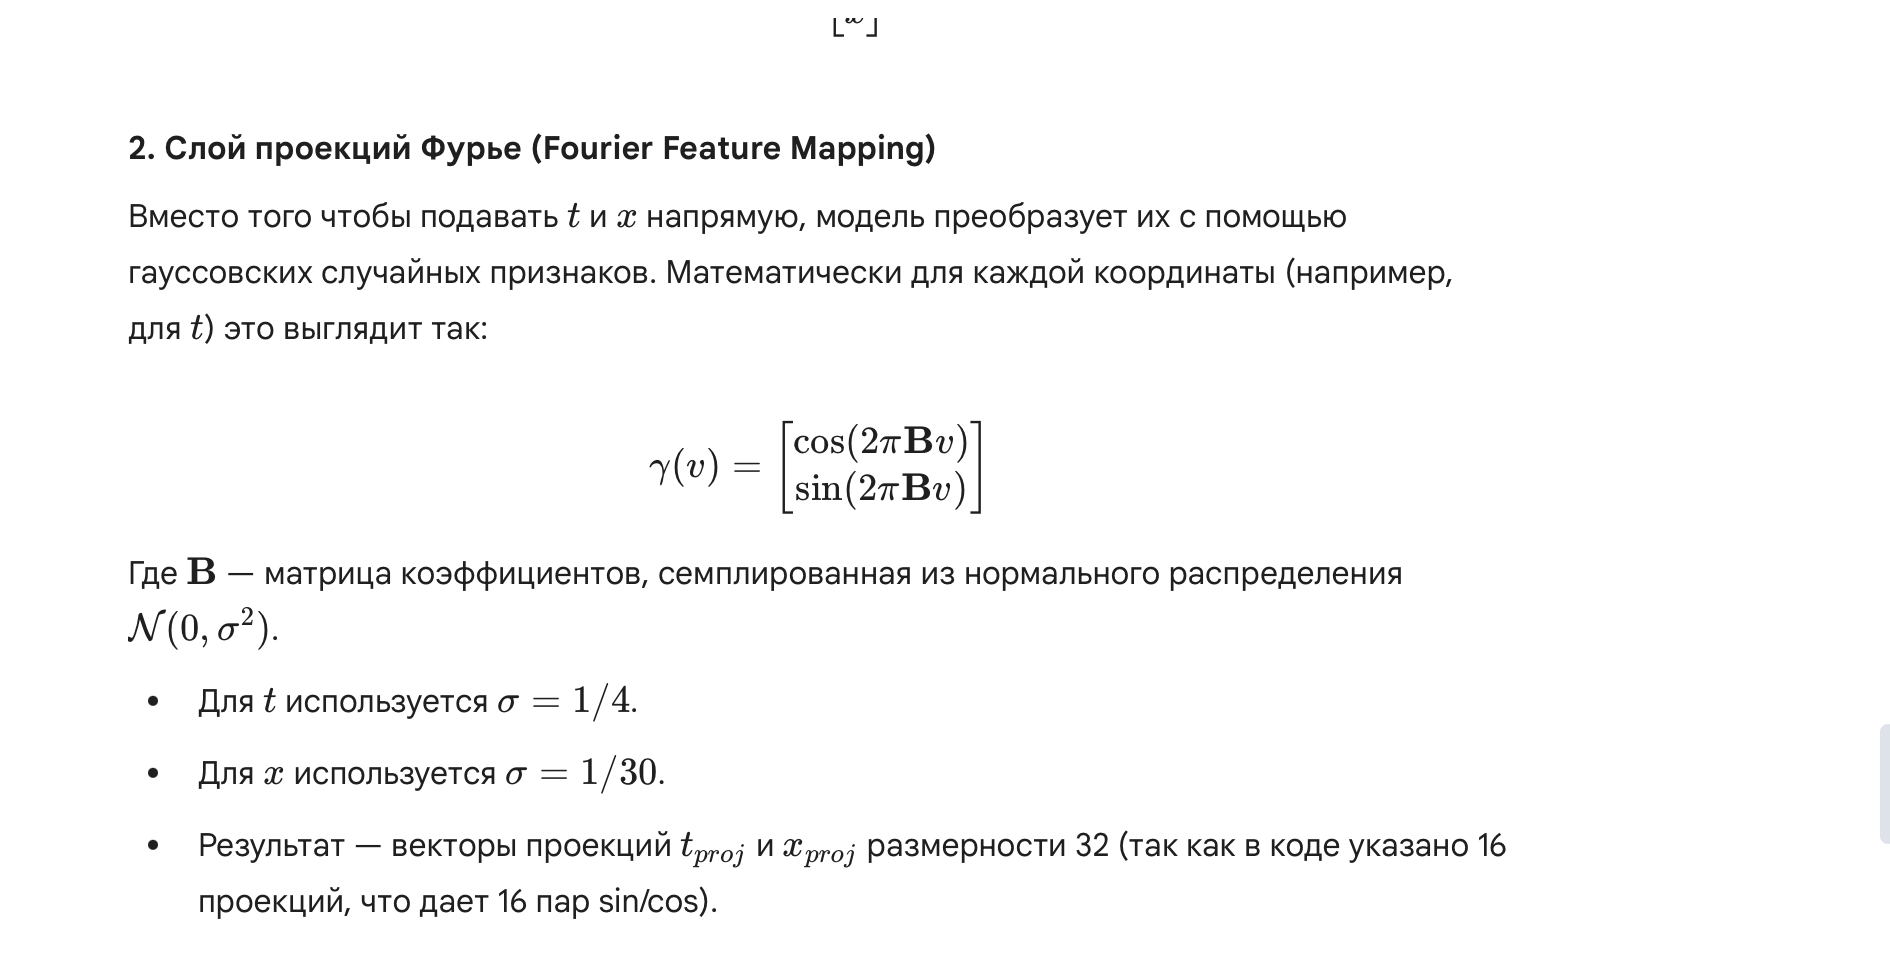

In [17]:
class MyModel(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, act="linear"):
        super().__init__()
        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = [
            tf.keras.layers.Dense(hidden_dim, activation="tanh")
            for _ in range(num_hidden_layers)
        ]
        self.output_layer = tf.keras.layers.Dense(1, activation=act)

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)

        return self.output_layer(h)


Невязка

In [18]:
def get_r(model, X_r):
    t = X_r[:, 0:1]
    x = X_r[:, 1:2]

    with tf.GradientTape(persistent=True) as tape4:
        tape4.watch([t, x])
        with tf.GradientTape(persistent=True) as tape3:
            tape3.watch([t, x])
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch([t, x])
                with tf.GradientTape(persistent=True) as tape1:
                    tape1.watch([t, x])
                    u = model(tf.concat([t, x], axis=1))
                u_x = tape1.gradient(u, x)
                u_t = tape1.gradient(u, t)
            u_xx = tape2.gradient(u_x, x)
        u_xxx = tape3.gradient(u_xx, x)
    u_xxxx = tape4.gradient(u_xxx, x)

    del tape1, tape2, tape3, tape4

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx)


In [19]:
def get_boundary_residuals_from_exact(model, X_lb, X_ub):
    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2_pred:
        tape2_pred.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_pred:
            tape1_pred.watch([x_lb, x_ub])
            u_lb = model(tf.concat([t_lb, x_lb], axis=1))
            u_ub = model(tf.concat([t_ub, x_ub], axis=1))
        u_x_lb = tape1_pred.gradient(u_lb, x_lb)
        u_x_ub = tape1_pred.gradient(u_ub, x_ub)
    u_xx_lb = tape2_pred.gradient(u_x_lb, x_lb)
    u_xx_ub = tape2_pred.gradient(u_x_ub, x_ub)

    with tf.GradientTape(persistent=True) as tape2_exact:
        tape2_exact.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_exact:
            tape1_exact.watch([x_lb, x_ub])
            u_exact_lb = u_exact(t_lb, x_lb)
            u_exact_ub = u_exact(t_ub, x_ub)
        u_exact_x_lb = tape1_exact.gradient(u_exact_lb, x_lb)
        u_exact_x_ub = tape1_exact.gradient(u_exact_ub, x_ub)
    u_exact_xx_lb = tape2_exact.gradient(u_exact_x_lb, x_lb)
    u_exact_xx_ub = tape2_exact.gradient(u_exact_x_ub, x_ub)

    del tape1_pred, tape2_pred, tape1_exact, tape2_exact

    r_u = tf.concat([u_lb - u_exact_lb, u_ub - u_exact_ub], axis=0)
    r_ux = tf.concat([u_x_lb - u_exact_x_lb, u_x_ub - u_exact_x_ub], axis=0)
    r_uxx = tf.concat([u_xx_lb - u_exact_xx_lb, u_xx_ub - u_exact_xx_ub], axis=0)

    # Additional boundary condition: Neumann u_x = 0 at x = xmin/xmax
    r_ux_neumann = tf.concat([u_x_lb, u_x_ub], axis=0)

    return r_u, r_ux, r_uxx, r_ux_neumann


In [20]:
def compute_loss_components(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    r = get_r(model, X_r)
    phi_r = tf.reduce_mean(tf.square(w_r * r))

    r_u_b, r_ux_b, r_uxx_b, r_ux_neumann_b = get_boundary_residuals_from_exact(model, X_lb, X_ub)
    phi_b_u = tf.reduce_mean(tf.square(r_u_b))
    phi_b_ux = tf.reduce_mean(tf.square(r_ux_b))
    phi_b_uxx = tf.reduce_mean(tf.square(r_uxx_b))
    phi_b_neumann = tf.reduce_mean(tf.square(r_ux_neumann_b))

    # Keep the additional Neumann term softer to avoid over-constraining boundaries.
    phi_b = phi_b_u + phi_b_ux + phi_b_uxx + 0.2 * phi_b_neumann

    phi_0 = tf.constant(0.0, dtype=DTYPE)
    for i in range(len(X_data)):
        u_pred = model(X_data[i])
        phi_0 += tf.reduce_mean(tf.square(w_0 * (u_data[i] - u_pred)))

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann


# Градиент 
Строится для того чтобы найти Минимум ошибки (функции потель )

In [21]:
def get_grad(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    with tf.GradientTape() as tape:
        total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann = compute_loss_components(
            model,
            X_r,
            X_data,
            u_data,
            X_lb,
            X_ub,
            w_r,
            w_0,
            lambda_r,
            lambda_b,
            lambda_0,
        )

    grad_theta = tape.gradient(total_loss, model.trainable_variables)
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann, grad_theta


In [22]:
model = MyModel()
_ = model(tf.zeros((1, 2), dtype=DTYPE))

CHECKPOINT_DIR = Path("stage_1/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_PATH = CHECKPOINT_DIR / "ks_pinn.weights.h5"

loaded_from_checkpoint = False
if WEIGHTS_PATH.exists():
    model.load_weights(str(WEIGHTS_PATH))
    loaded_from_checkpoint = True
    print(f"Loaded pretrained weights from: {WEIGHTS_PATH}")
else:
    print(f"No pretrained weights found at {WEIGHTS_PATH}.")
    print("Model will train from scratch and save weights after training.")

lr = 2e-4
optim = tf.keras.optimizers.Adam(learning_rate=lr)


No pretrained weights found at stage_1/checkpoints/ks_pinn.weights.h5.
Model will train from scratch and save weights after training.


Для всего графика построили пирближение 

In [23]:
x_plot = np.linspace(xmin, xmax, 400).reshape(-1, 1)
y_ref_0 = u_exact(np.full_like(x_plot, tmin), x_plot).numpy().reshape(-1)
y_ref_t = u_exact(np.full_like(x_plot, tmax), x_plot).numpy().reshape(-1)
y_min = min(y_ref_0.min(), y_ref_t.min())
y_max = max(y_ref_0.max(), y_ref_t.max())
y_pad = 0.10 * (y_max - y_min + 1e-12)
PLOT_YLIM = (y_min - y_pad, y_max + y_pad)


def plot(c=0.0, ax=None):
    t = np.full_like(x_plot, c)
    xt = np.hstack([t, x_plot])
    xt_tf = tf.convert_to_tensor(xt, dtype=DTYPE)

    u_pred = model(xt_tf).numpy().reshape(-1)
    u_ref = u_exact(t, x_plot).numpy().reshape(-1)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
        created_fig = True

    ax.plot(x_plot, u_pred, lw=2, label="PINN prediction")
    ax.plot(x_plot, u_ref, "--", lw=2, label="Exact solution")
    ax.set_xlabel("x")
    ax.set_ylabel("u(t, x)")
    ax.set_title(f"Solution slice at t={c:.2f}")
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if created_fig:
        plt.tight_layout()
        plt.show()


def plot_slices(times=(0.0, 4.0)):
    fig, axes = plt.subplots(1, len(times), figsize=(6 * len(times), 3.5), sharey=True)
    if len(times) == 1:
        axes = [axes]
    for ax, current_t in zip(axes, times):
        plot(current_t, ax=ax)
    plt.tight_layout()
    plt.show()


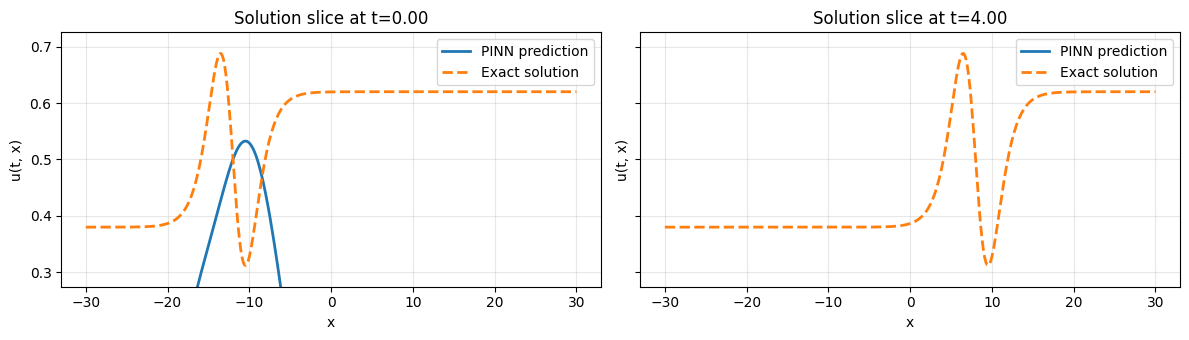

In [24]:
plot_slices((0.0, 4.0))


In [25]:
@tf.function
def train_step():
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann, grad_theta = get_grad(
        model,
        X_r,
        X_data,
        u_data,
        X_lb,
        X_ub,
        w_r,
        w_0,
        lambda_r,
        lambda_b,
        lambda_0,
    )
    optim.apply_gradients(zip(grad_theta, model.trainable_variables))
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann


BASE_STEPS = 13000
FINETUNE_STEPS = 2000
CONTINUE_TRAINING_IF_LOADED = False

if loaded_from_checkpoint:
    N = FINETUNE_STEPS if CONTINUE_TRAINING_IF_LOADED else 0
else:
    N = BASE_STEPS

print(f"Training steps selected: {N}")

history = {
    "step": [],
    "total": [],
    "phi_r": [],
    "phi_b": [],
    "phi_0": [],
    "phi_b_u": [],
    "phi_b_ux": [],
    "phi_b_uxx": [],
    "phi_b_neumann": [],
}

t0 = time()

if N > 0:
    for i in range(1, N + 1):
        total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann = train_step()

        history["step"].append(i)
        history["total"].append(float(total_loss))
        history["phi_r"].append(float(phi_r))
        history["phi_b"].append(float(phi_b))
        history["phi_0"].append(float(phi_0))
        history["phi_b_u"].append(float(phi_b_u))
        history["phi_b_ux"].append(float(phi_b_ux))
        history["phi_b_uxx"].append(float(phi_b_uxx))
        history["phi_b_neumann"].append(float(phi_b_neumann))

        if i % 50 == 0:
            print(
                f"It {i:05d}: total={float(total_loss):.8e}, "
                f"phi_r={float(phi_r):.8e}, phi_b={float(phi_b):.8e}, phi_0={float(phi_0):.8e}"
            )

        if i % 1000 == 0:
            plot_slices((0.0, 4.0))
else:
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, phi_b_neumann = compute_loss_components(
        model,
        X_r,
        X_data,
        u_data,
        X_lb,
        X_ub,
        w_r,
        w_0,
        lambda_r,
        lambda_b,
        lambda_0,
    )

    history["step"].append(0)
    history["total"].append(float(total_loss))
    history["phi_r"].append(float(phi_r))
    history["phi_b"].append(float(phi_b))
    history["phi_0"].append(float(phi_0))
    history["phi_b_u"].append(float(phi_b_u))
    history["phi_b_ux"].append(float(phi_b_ux))
    history["phi_b_uxx"].append(float(phi_b_uxx))
    history["phi_b_neumann"].append(float(phi_b_neumann))

    print("Training skipped: using pretrained weights without additional optimization.")

model.save_weights(str(WEIGHTS_PATH))
print(f"Weights saved to: {WEIGHTS_PATH}")
print(f"\nComputation time: {time() - t0:.2f} seconds")
print("History keys:", list(history.keys()))


Training steps selected: 13000


KeyboardInterrupt: 

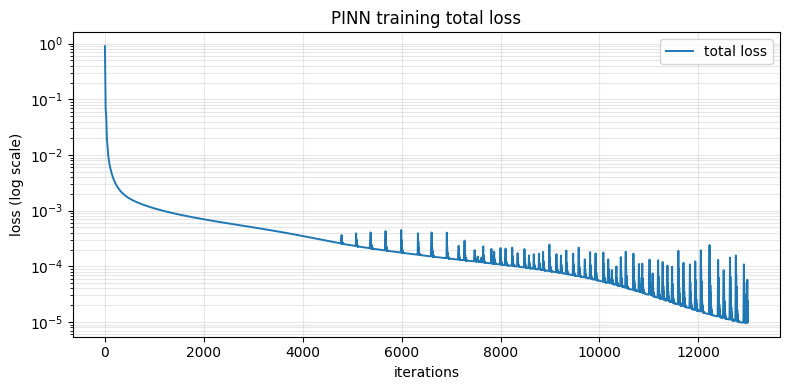

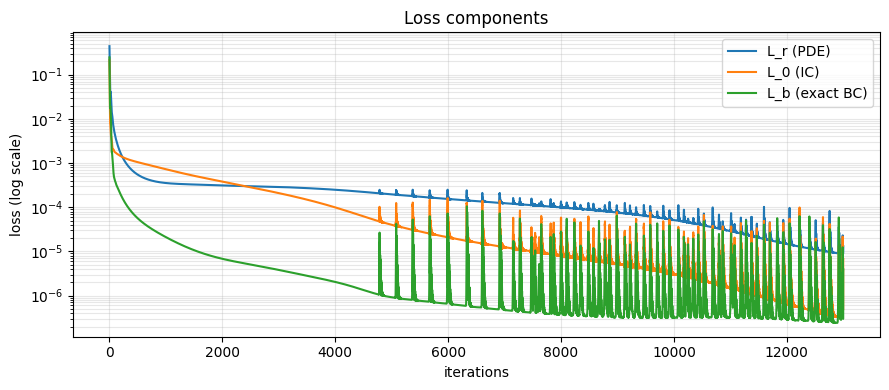

In [ ]:
# Training curves: total loss in log scale + components
steps = np.array(history["step"])
total = np.array(history["total"])
eps = 1e-12

plt.figure(figsize=(8, 4))
plt.semilogy(steps, total + eps, lw=1.4, label="total loss")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("PINN training total loss")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.semilogy(steps, np.array(history["phi_r"]) + eps, label="L_r (PDE)")
plt.semilogy(steps, np.array(history["phi_0"]) + eps, label="L_0 (IC)")
plt.semilogy(steps, np.array(history["phi_b"]) + eps, label="L_b (exact BC + Neumann)")
plt.semilogy(steps, np.array(history["phi_b_neumann"]) + eps, label="L_b_neumann (u_x = 0)")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("Loss components")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Top jumps (step, relative_change):
step=12230, rel_change=2.705906e+00
step=12054, rel_change=1.535390e+00
step=12763, rel_change=1.520416e+00
step=12645, rel_change=1.381574e+00
step=12235, rel_change=1.249937e+00
step=12926, rel_change=1.108316e+00
step=12236, rel_change=1.037147e+00
step=12769, rel_change=9.875857e-01
step=12652, rel_change=9.769989e-01
step=12646, rel_change=9.760628e-01

Summary:
mean rel jump: 2.529770e-02
median rel jump: 4.984556e-04
95th percentile: 1.576865e-01


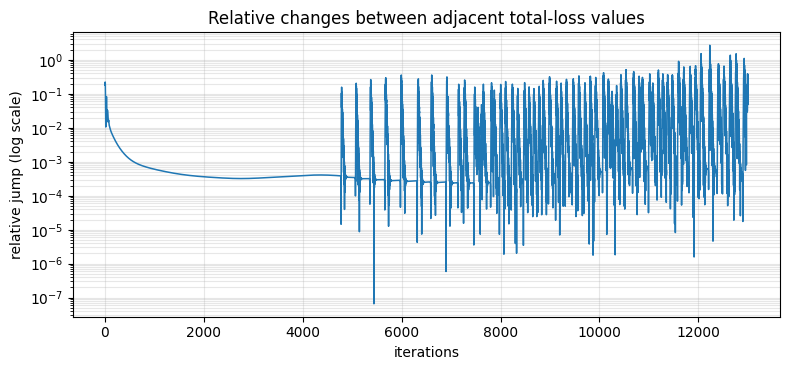

In [ ]:
# Smoothness diagnostics: relative jumps |L[i]-L[i-1]| / L[i-1]
steps = np.array(history["step"])
loss_vals = np.array(history["total"])
eps = 1e-12

rel_jump = np.abs(np.diff(loss_vals)) / (np.abs(loss_vals[:-1]) + eps)
jump_steps = steps[1:]

top_k = 10 if rel_jump.size >= 10 else rel_jump.size
top_idx = np.argsort(rel_jump)[-top_k:][::-1]

print("Top jumps (step, relative_change):")
for idx in top_idx:
    print(f"step={int(jump_steps[idx])}, rel_change={rel_jump[idx]:.6e}")

print("\nSummary:")
print(f"mean rel jump: {rel_jump.mean():.6e}")
print(f"median rel jump: {np.median(rel_jump):.6e}")
print(f"95th percentile: {np.percentile(rel_jump, 95):.6e}")

plt.figure(figsize=(8, 3.8))
plt.semilogy(jump_steps, rel_jump + eps, lw=1.1)
plt.xlabel("iterations")
plt.ylabel("relative jump (log scale)")
plt.title("Relative changes between adjacent total-loss values")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
